In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set ()






In [ ]:
df = pd.read_csv ('/content/car_prediction_data.csv')
len(df)

301

In [ ]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [ ]:
len(df.columns)

9

In [ ]:
df.columns

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
for col in df.columns:
    # 1) How many unique values?
    count_unique = df[col].nunique()
    print(f"{col}: {count_unique}")

    # 2) Top 5 most frequent values
    top5 = df[col].value_counts().nlargest(5)
    print(top5)

    # 3) Separator
    print("\n" + "*" * 20 + "\n")


Car_Name: 98
Car_Name
city             26
corolla altis    16
verna            14
fortuner         11
brio             10
Name: count, dtype: int64

********************

Year: 16
Year
2015    61
2016    50
2014    38
2017    35
2013    33
Name: count, dtype: int64

********************

Selling_Price: 156
Selling_Price
0.45    8
0.60    8
4.50    7
5.25    7
4.75    6
Name: count, dtype: int64

********************

Present_Price: 147
Present_Price
9.40     15
13.60    13
5.70      8
1.47      7
4.43      7
Name: count, dtype: int64

********************

Kms_Driven: 206
Kms_Driven
15000    9
45000    9
40000    5
25000    5
50000    5
Name: count, dtype: int64

********************

Fuel_Type: 3
Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

********************

Seller_Type: 2
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64

********************

Transmission: 2
Transmission
Manual       261
Automatic     40
Name: count, dtyp

In [ ]:

df['Car_Name'] = (
    df['Car_Name']
    .astype(str)
    .str.strip()
    .str.capitalize()                          # capitalizes each word
    .str.replace(' ', '_', regex=False)  # literal space → underscore
)


In [ ]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


Exploratory Data Analysis

In [ ]:

pd.set_option('display.float_format', '{:,.2f}'.format)
df.describe()


,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.00,301.00,301.00,301.00,301.00
mean,"2,013.63",4.66,7.63,"36,947.21",0.04
std,2.89,5.08,8.64,"38,886.88",0.25
min,"2,003.00",0.10,0.32,500.00,0.00
25%,"2,012.00",0.90,1.20,"15,000.00",0.00
50%,"2,014.00",3.60,6.40,"32,000.00",0.00
75%,"2,016.00",6.00,9.90,"48,767.00",0.00
max,"2,018.00",35.00,92.60,"500,000.00",3.00


In [ ]:
df.describe(include=['object'])

,Car_Name,Fuel_Type,Seller_Type,Transmission
count,301,301,301,301
unique,98,3,2,2
top,City,Petrol,Dealer,Manual
freq,26,239,195,261


Target variable analysis(price)


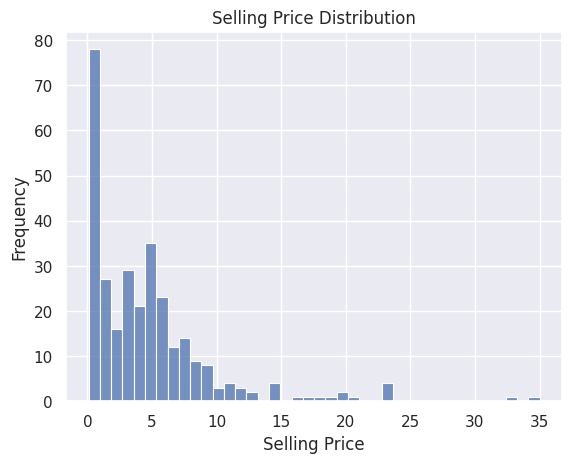

In [ ]:
# plt.figure(figsize=(6,4))
sns.histplot(df.Selling_Price, bins=40)
plt.ylabel('Frequency')  # Corrected function name
plt.xlabel('Selling Price')
plt.title('Selling Price Distribution')

plt.show()

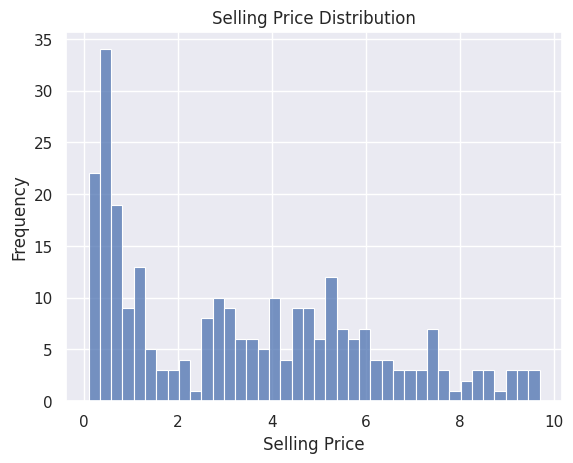

In [ ]:
# plt.figure(figsize=(6,4))
sns.histplot(df.Selling_Price[df.Selling_Price < 10] , bins=40)
plt.ylabel('Frequency')  # Corrected function name
plt.xlabel('Selling Price')
plt.title('Selling Price Distribution')

plt.show()

Log Transformation

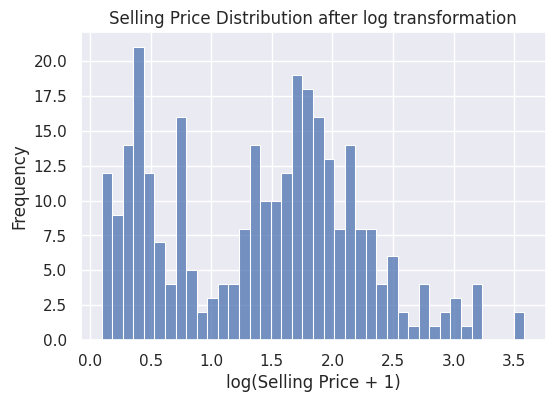

In [ ]:
df['log_Selling_Price'] = np.log1p(df.Selling_Price)

# Correcting the typo in figsize
plt.figure(figsize=(6, 4))  # Corrected function name
sns.histplot(df['log_Selling_Price'], bins=40)

plt.ylabel('Frequency')  # Corrected function name
plt.xlabel('log(Selling Price + 1)')
plt.title('Selling Price Distribution after log transformation')

plt.show()

In [ ]:
df.Selling_Price.skew()

2.493422417797524

In [ ]:
df.log_Selling_Price.skew()

0.115141322922288

Check missing values

In [ ]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0
log_Selling_Price,0


Check categorical columns

In [ ]:
# Assuming df is your DataFrame
string_columns = df.select_dtypes(include='object').columns


In [ ]:
string_columns

Index(['Car_Name', 'Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object')

In [ ]:
df.Car_Name.value_counts()

,count
Car_Name,
city,26
corolla altis,16
verna,14
fortuner,11
brio,10
...,...
Honda CB Trigger,1
Yamaha FZ S,1
Bajaj Pulsar 135 LS,1


Validation framework

In [ ]:
np.random.seed(2)
n = len(df)
n_val = int(0.2 * n)
n_test = int(0.2 * n)
n_train = n - (n_val + n_test)
print('No. of rows for training: ', n_train)
print('No. of rows for validation:' , n_val)
print('No. of rows for testing:', n_test)

No. of rows for training:  181
No. of rows for validation: 60
No. of rows for testing: 60


In [ ]:
idx = np.arange(n)
print(idx)
np.random.shuffle(idx)
print(idx)

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245 24

In [ ]:
df_shuffled = df.iloc[idx]
print (df.index)
print (df_shuffled.index)

RangeIndex(start=0, stop=301, step=1)
Index([ 99, 161,  89,  30, 232, 290,  35,   7, 183,  13,
       ...
       213, 296,  95, 162, 263,  75,  22,  72,  15, 168],
      dtype='int64', length=301)


In [ ]:
df_shuffled

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
99,fortuner,2010,9.65,20.450,50024,Diesel,Dealer,Manual,0
161,TVS Apache RTR 180,2014,0.45,0.826,23000,Petrol,Individual,Manual,0
89,etios g,2014,4.75,6.760,40000,Petrol,Dealer,Manual,0
30,ritz,2012,3.10,5.980,51439,Diesel,Dealer,Manual,0
232,elantra,2015,11.45,14.790,12900,Petrol,Dealer,Automatic,0
...,...,...,...,...,...,...,...,...,...
75,etios g,2015,3.95,6.800,36000,Petrol,Dealer,Manual,0
22,sx4,2011,4.40,8.010,50000,Petrol,Dealer,Automatic,0
72,corolla altis,2013,7.45,18.610,56001,Petrol,Dealer,Manual,0
15,ertiga,2016,7.75,10.790,43000,Diesel,Dealer,Manual,0


In [ ]:
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [ ]:
df_train = df_shuffled.iloc[:n_train].copy()
df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
df_test = df_shuffled.iloc[n_train+n_val:].copy()

In [ ]:
df_train.shape

(181, 9)

In [ ]:
df_val.shape

(60, 9)

In [ ]:
df_test.shape

(60, 9)

In [ ]:
# Add a log-transformed column 'log_Selling_Price' to each DataFrame
df_train['log_Selling_Price'] = np.log(df_train['Selling_Price'] + 1)
df_val['log_Selling_Price'] = np.log(df_val['Selling_Price'] + 1)
df_test['log_Selling_Price'] = np.log(df_test['Selling_Price'] + 1)

# Now assign the target variable from the new column
y_train = df_train['log_Selling_Price'].values
y_val = df_val['log_Selling_Price'].values
y_test = df_test['log_Selling_Price'].values


Daseline Solution

In [ ]:
base =['Year', 'Selling_Price', 'Present_Price','Kms_Driven','Owner']
#base = ['Year', 'Selling_Price']

In [ ]:
df[base]

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
0,2014,3.35,5.59,27000,0
1,2013,4.75,9.54,43000,0
2,2017,7.25,9.85,6900,0
3,2011,2.85,4.15,5200,0
4,2014,4.60,6.87,42450,0
...,...,...,...,...,...
296,2016,9.50,11.60,33988,0
297,2015,4.00,5.90,60000,0
298,2009,3.35,11.00,87934,0
299,2017,11.50,12.50,9000,0


In [ ]:
df[base].isnull().sum()

,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Owner,0


In [ ]:
df_train_numeric = df_train.select_dtypes(include=['number'])
df_train_numeric.corr()


,Year,Selling_Price,Present_Price,Kms_Driven,Owner
Year,1.000000,0.241270,-0.100047,-0.676830,-0.210349
Selling_Price,0.241270,1.000000,0.854028,0.017949,-0.091835
Present_Price,-0.100047,0.854028,1.000000,0.325151,0.062684
Kms_Driven,-0.676830,0.017949,0.325151,1.000000,0.153724
Owner,-0.210349,-0.091835,0.062684,0.153724,1.000000


<Axes: >

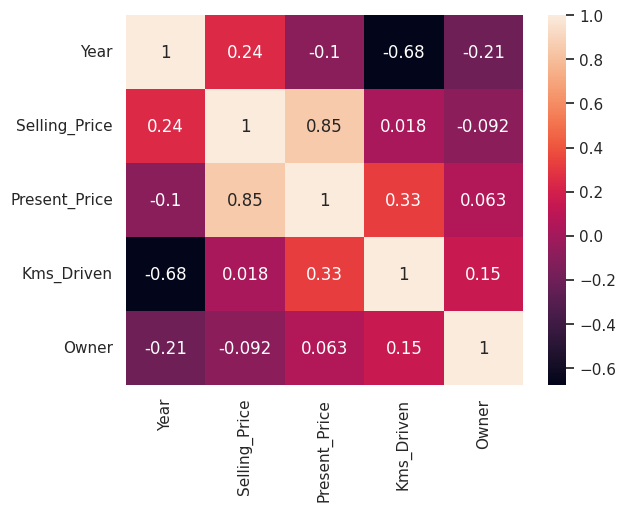

In [ ]:
df_train_numeric = df_train.select_dtypes(include=['number'])
sns.heatmap(df_train_numeric.corr(), annot=True)


In [ ]:
def linear_regression(xi):
  n =len(xi)
  pred = w0
  for j in range(n):
    pred += w[j]*xi[j]
    return pred

In [ ]:
def train_linear_regression(x, y):
    ones = np.ones(x.shape[0])  # Create a column of ones for the intercept term
    x = np.column_stack([ones, x])  # Add the ones column to the input feature matrix

    XTX = x.T.dot(x)  # Compute the dot product of x.T and x
    XTX_inv = np.linalg.inv(XTX)  # Compute the inverse of XTX
    w = XTX_inv.dot(x.T).dot(y)  # Compute the weights (w)

    return w[0], w[1:]  # Return the intercept (w[0]) and the coefficients (w[1:])

In [ ]:
x_train = prepare_x(df_train)
w_0, w = train_linear_regression(x_train, y_train)
y_pred = w_0 + x_train.dot(w)

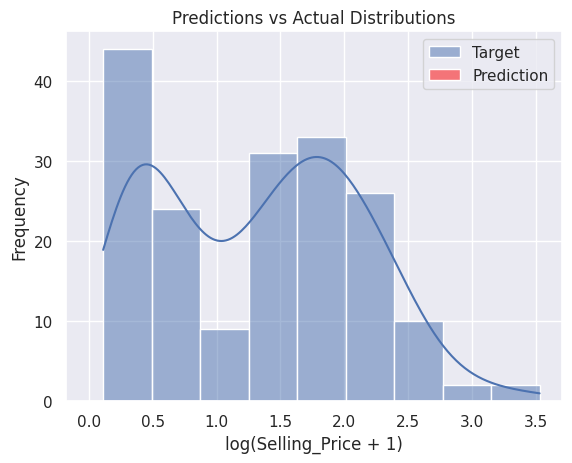

In [ ]:
# Plot the histograms comparing actual values and predictions
sns.histplot(y_train, label='Target', kde=True)
sns.histplot(y_pred, label='Prediction', color='red', kde=True)

# Add a legend
plt.legend()

# Label the axes
plt.ylabel('Frequency')
plt.xlabel('log(Selling_Price + 1)')

# Add a title
plt.title('Predictions vs Actual Distributions')

# Display the plot
plt.show()

In [ ]:
def rsme (y, y_pred):
  error = y_pred - y
  mse = (error ** 2).mean()
  return np.sqrt(mse)

In [ ]:


# Define RMSE function
def rmse(y_true, y_pred):
    return np.sqrt(((y_true - y_pred) ** 2).mean())

# Calculate RMSE
rmse_value = rmse(y_train, y_pred)
print("RMSE:", rmse_value)



RMSE: nan


In [ ]:
# Preprocess the validation features (add intercept column)
x_val = prepare_x(df_val)

# Make predictions using the trained model
y_pred = x_val.dot(w)  # This includes both intercept and feature weights (w already includes intercept)

# If you need to manually add the intercept term, use:
# y_pred = w_0 + x_val.dot(w)  # If w does not include intercept


In [ ]:
rsme(y_val, y_pred)

np.float64(nan)

Simple Feature Engineering

In [ ]:
def prepare_x (df):
  df = df.copy()
  features = base.copy()
  df['age']= 2017 - df.Year
  features.append('age')
  df_num = df[features]
  df_num = df_num.fillna(df_num.mean())
  x = df_num.values
  return x

Handling Categorical Variables
